
# Lab_5: FEM 1D

### Exercise 1: solve the EDO

Use FEM to solve the next EDO (use the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
\dfrac{d^2y}{dx^2}=-xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(x-2)-x
\end{equation}

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.sparse.linalg import spsolve

def fem_poisson_1d(source, a, b, ua, ub, n_elems):
    """Resuelve -u'' = source en [a,b] con condiciones de Dirichlet u(a)=ua, u(b)=ub."""
    # Nodos de la malla uniforme y paso h entre nodos.
    x_nodes = np.linspace(a, b, n_elems + 1)
    h = (b - a) / n_elems
    n_internal = n_elems - 1

    # Matriz de rigidez de elementos lineales 1D.
    A = np.zeros((n_internal, n_internal))
    rhs = np.zeros(n_internal)

    for i in range(n_internal):
        A[i, i] = 2.0 / h
        if i > 0:
            A[i, i - 1] = -1.0 / h
        if i < n_internal - 1:
            A[i, i + 1] = -1.0 / h

    # Ensamblado de la carga por cada elemento.
    for elem in range(n_elems):
        x_left = x_nodes[elem]
        x_right = x_nodes[elem + 1]

        # Funciones base lineales en el elemento actual.
        phi_left = lambda x: (x_right - x) / h
        phi_right = lambda x: (x - x_left) / h

        # Integrar source(x) contra cada función base.
        f_left, _ = quad(lambda x: source(x) * phi_left(x), x_left, x_right)
        f_right, _ = quad(lambda x: source(x) * phi_right(x), x_left, x_right)

        if 1 <= elem <= n_elems - 1:
            rhs[elem - 1] += f_left
        if 1 <= elem + 1 <= n_elems - 1:
            rhs[elem] += f_right

    # Ajuste de la carga para imponer condiciones de frontera Dirichlet.
    rhs[0] += ua / h
    rhs[-1] += ub / h

    # Resolver el sistema y reconstruir la solución completa.
    u_internal = spsolve(A, rhs)
    u_full = np.concatenate(([ua], u_internal, [ub]))
    return x_nodes, u_full


### Exercise 1: FEM para $y'' = -x e^x$

La ecuación se transforma a la forma de Poisson con fuente $f(x)=x e^x$ para poder resolver
$-y'' = f(x)$. A continuación se arma una malla uniforme y se calcula la solución FEM con elementos lineales.

Exercise 1: error máximo aproximado = 2.069e-04


/tmp/ipykernel_22961/3224466472.py:47: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  u_internal = spsolve(A, rhs)


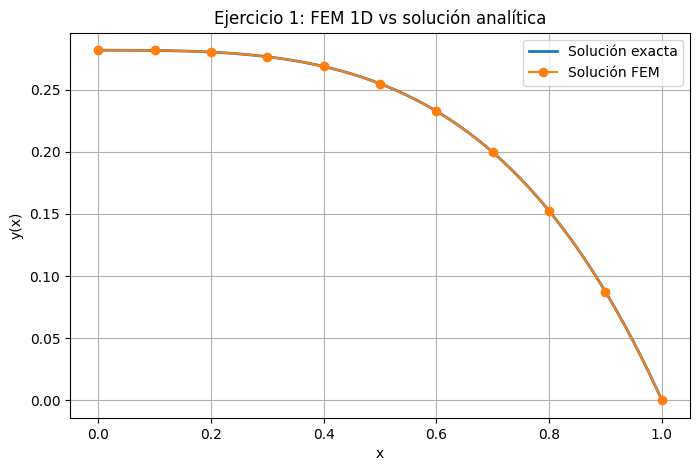

In [2]:
# Definir la fuente f(x) del problema y la solución analítica conocida.
source_1 = lambda x: x * np.exp(x)
exact_1 = lambda x: 1 - np.e - np.exp(x) * (x - 2) - x

# Resolver la PDE usando FEM con una malla de 40 elementos.
x_1, u_1 = fem_poisson_1d(source_1, 0.0, 1.0, 3 - np.e, 0.0, n_elems=40)

# Interpolar la solución FEM en una malla más fina para comparar.
x_fine = np.linspace(0.0, 1.0, 250)
exact_values = exact_1(x_fine)
approx_values = np.interp(x_fine, x_1, u_1)
max_error_1 = np.max(np.abs(approx_values - exact_values))
print(f"Exercise 1: error máximo aproximado = {max_error_1:.3e}")

# Graficar solución exacta y aproximación FEM.
plt.figure(figsize=(8, 5))
plt.plot(x_fine, exact_values, label='Solución exacta', linewidth=2)
plt.plot(x_1, u_1, 'o-', label='Solución FEM', markevery=4)
plt.title('Ejercicio 1: FEM 1D vs solución analítica')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()
plt.grid(True)
plt.show()


### Exercise 2: Solve the EDO:  

see pag 36: https://cimec.org.ar/foswiki/pub/Main/Cimec/CursoFEM/cursofem_1.pdf

$-\dfrac{d^2U}{dx^2}(x)=\sin(\pi x)\,,$
in $0\le x\le 1$, with $U(0)=U(1)=0$.

The exact solution is known $U(x)=\dfrac{1}{\pi^2}\sin(\pi x)$.

Exercise 2: error máximo aproximado = 7.736e-05


/tmp/ipykernel_22961/3224466472.py:47: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  u_internal = spsolve(A, rhs)


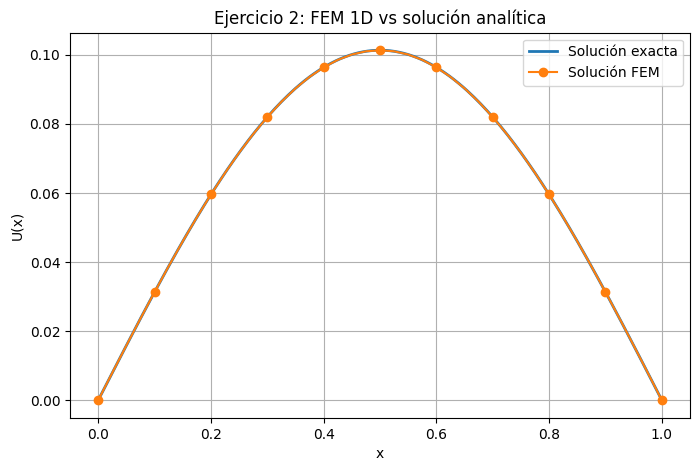

In [3]:
# Definir la fuente f(x) para el segundo problema y la solución exacta.
source_2 = lambda x: np.sin(np.pi * x)
exact_2 = lambda x: np.sin(np.pi * x) / (np.pi**2)

# Resolver la segunda PDE en [0,1] con condiciones de contorno homogéneas.
x_2, u_2 = fem_poisson_1d(source_2, 0.0, 1.0, 0.0, 0.0, n_elems=40)

# Evaluar la solución en una malla fina para comparar con el valor analítico.
x_fine2 = np.linspace(0.0, 1.0, 250)
approx_values_2 = np.interp(x_fine2, x_2, u_2)
exact_values_2 = exact_2(x_fine2)
max_error_2 = np.max(np.abs(approx_values_2 - exact_values_2))
print(f"Exercise 2: error máximo aproximado = {max_error_2:.3e}")

# Graficar la solución FEM y la solución exacta.
plt.figure(figsize=(8, 5))
plt.plot(x_fine2, exact_values_2, label="Solución exacta", linewidth=2)
plt.plot(x_2, u_2, "o-", label="Solución FEM", markevery=4)
plt.title("Ejercicio 2: FEM 1D vs solución analítica")
plt.xlabel("x")
plt.ylabel("U(x)")
plt.legend()
plt.grid(True)
plt.show()
